In [1]:
import os
from concurrent .futures .thread import ThreadPoolExecutor

import pandas as pd
from matplotlib import pyplot as plt
from sympy .printing .pretty .pretty_symbology import line_width

os .environ ['US_TIGER_SHAPEFILE_PATH']='/Users/aaronspaulding/Documents/PycharmProjects/outagescraping/TIGER/tl_2020_us_county/tl_2020_us_county.shp'
os .environ ['CANADA_CENSUS_DIVISIONS_PATH']='/Users/aaronspaulding/Documents/PycharmProjects/outagescraping/CanadaBoundaries/lcd_000b21a_e/lcd_000b21a_e.shp'
os .environ ['DATA_CACHE_PATH']='/Users/aaronspaulding/Documents/PycharmProjects/research_summer_2025/data_cache/'


In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd

import contextily as ctx

import matplotlib .pyplot as plt

from shapely .geometry import Polygon

from tqdm import tqdm

import h3
import h3pandas

from pyproj import Transformer


In [28]:
cells =gpd .read_feather ('/Users/aaronspaulding/Documents/PycharmProjects/research_summer_2025/data_cache/aggregated_static_variables.feather')


# Open SVI Data


In [21]:
svi_data_path ='/Users/aaronspaulding/data/SVI_2022_US.csv'


In [22]:
svi_data =pd .read_csv (svi_data_path ,dtype ='str')


In [38]:
cells ['FIPS']=cells ['STATEFP']+cells ['COUNTYFP']+cells ['TRACTFP']


In [39]:
svi_data ['svi_overall']=svi_data ['RPL_THEMES'].astype (float )

svi_data ['svi_socioeconomic_status']=svi_data ['RPL_THEME1'].astype (float )
svi_data ['svi_household_characteristics']=svi_data ['RPL_THEME2'].astype (float )
svi_data ['svi_racial_and_ethnic_minority']=svi_data ['RPL_THEME3'].astype (float )
svi_data ['svi_housing_type_and_transportation']=svi_data ['RPL_THEME4'].astype (float )

svi_columns =['svi_overall','svi_socioeconomic_status','svi_household_characteristics','svi_racial_and_ethnic_minority','svi_housing_type_and_transportation']


In [40]:
cells_merged =cells .merge (svi_data [svi_columns +['FIPS']],how ='left',on ='FIPS')


In [48]:
for column in svi_columns :
    idx =cells_merged [column ]<0.0
    cells_merged .loc [idx ,column ]=0.0

    idx =cells_merged [column ].isna ()
    cells_merged .loc [idx ,column ]=0.0


In [50]:
cells_merged [svi_columns +['index']].copy ().reset_index (drop =True ).to_feather ('/Users/aaronspaulding/Documents/PycharmProjects/research_summer_2025/data_cache/static_variables_svi.feather')


In [1]:
NJ_h3_cells =cells_merged [cells_merged ['STATEFP']=='34'].copy ().reset_index (drop =True )


NameError: name 'cells_merged' is not defined

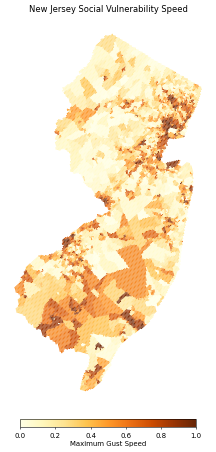

In [75]:
fig ,ax =plt .subplots (figsize =(12 ,10 ),dpi =50 )
fig .patch .set_facecolor ('white')

NJ_h3_cells .plot (
ax =ax ,
column ='svi_overall',
cmap ='YlOrBr',
linewidth =0 ,
edgecolor ='none',
legend =True ,
vmin =0. ,
vmax =1. ,
legend_kwds ={
'label':'Maximum Gust Speed',
'shrink':0.3 ,
'orientation':'horizontal',
'pad':0.02
}
)

ax .set_title ('New Jersey Social Vulnerability Speed')
ax .axis ('off')

plt .tight_layout ()
plt .savefig ('images/NJ_svi.png',dpi =300 ,bbox_inches ='tight',pad_inches =0.1 )
plt .show ()


In [33]:
cells


,index,geometry,h3_code,STATEFP,COUNTYFP,TRACTFP,ALAND,AWATER,B01001_001E,B19001_001E,...,Con Edison,Dominion Energy,EverSource,FirstEnergy,Duke Energy,Public Service Electric and Gas,FULL_COUNTY_FIPS,county_map,state_map,FIPS
0,8826490001fffff,"POLYGON ((-87.07959 34.95023, -87.07462 34.952...",0,01,083,020300,1450296914,122310594,4061.0,1160.0,...,False,False,False,False,False,False,01083,41,0,01083020300
1,8826490003fffff,"POLYGON ((-87.07492 34.94263, -87.06994 34.944...",1,01,083,020300,1450296914,122310594,4061.0,1160.0,...,False,False,False,False,False,False,01083,41,0,01083020300
2,8826490005fffff,"POLYGON ((-87.08939 34.95088, -87.08441 34.952...",2,01,083,020300,1450296914,122310594,4061.0,1160.0,...,False,False,False,False,False,False,01083,41,0,01083020300
3,8826490007fffff,"POLYGON ((-87.08472 34.94329, -87.07974 34.945...",3,01,083,020300,1450296914,122310594,4061.0,1160.0,...,False,False,False,False,False,False,01083,41,0,01083020300
4,8826490009fffff,"POLYGON ((-87.07446 34.95716, -87.06949 34.959...",4,01,083,020300,1450296914,122310594,4061.0,1160.0,...,False,False,False,False,False,False,01083,41,0,01083020300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3571567,884cee7b65fffff,"POLYGON ((-66.11811 18.44039, -66.11475 18.443...",3571567,72,033,990201,12515561,5615090,NaN,NaN,...,False,False,False,False,False,False,72033,1291,22,72033990201
3571568,884cee7b67fffff,"POLYGON ((-66.11361 18.4356, -66.11025 18.4386...",3571568,72,061,040101,71444633,468303,NaN,NaN,...,False,False,False,False,False,False,72061,1306,22,72061040101
3571569,884cee7b69fffff,"POLYGON ((-66.10804 18.44952, -66.10468 18.452...",3571569,72,127,004200,124029902,75277895,NaN,NaN,...,False,False,False,False,False,False,72127,1339,22,72127004200
3571570,884cee7b6bfffff,"POLYGON ((-66.10353 18.44473, -66.10017 18.447...",3571570,72,127,004200,124029902,75277895,NaN,NaN,...,False,False,False,False,False,False,72127,1339,22,72127004200
